In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from astropy.io import fits

from VERSUS import SphericalVoids, setup_logging

In [2]:
cellsize = 4  # set cellsize used for void-finding

setup_logging()

np.random.seed(42)

# load galaxy positions from NERSC
f = fits.open("/pscratch/sd/n/ntbfin/emulator/hods/z0.5/yuan23_prior/c000_ph000/seed0/hod006.fits")[1].data
pos = np.array([f['X_PAR'], f['Y_PAR'], f['Z_PAR']]).T

# Cubic simulation data 

Run the void-finder with default input radii and void density threhold ($\delta_v=-0.8$).

In [3]:
sv = SphericalVoids(data_positions=pos, cellsize=cellsize,
                    boxsize=[2000,2000,2000], boxcenter=[0,0,0])
sv.run_voidfinding()

16:16:44 | INFO | meshbuilder.py | __init__ | Ln54 | Loading box-like data
16:16:44 | INFO | meshbuilder.py | size_mesh | Ln299 | Estimating volume and average galaxy separation (Ngal = 4000000)
16:16:45 | INFO | meshbuilder.py | create_mesh | Ln373 | Estimating mesh density (nmesh=[500 500 500])
16:16:46 | INFO | meshbuilder.py | _set_mesh_density | Ln210 | Applying initial smoothing of R=3.5 Mpc/h to the density field
16:16:52 | INFO | 2030979694.py | <module> | Ln1 | Building k-d trees
16:16:54 | INFO | 2030979694.py | <module> | Ln3 | Running spherical void-finder with 8 threads (delta < -0.80)
16:16:59 | INFO | 2030979694.py | <module> | Ln3 | No cells with delta < -0.80 for R=60.0 Mpc/h
16:17:04 | INFO | 2030979694.py | <module> | Ln3 | No cells with delta < -0.80 for R=58.0 Mpc/h
16:17:08 | INFO | 2030979694.py | <module> | Ln3 | No cells with delta < -0.80 for R=56.0 Mpc/h
16:17:13 | INFO | 2030979694.py | <module> | Ln3 | No cells with delta < -0.80 for R=54.0 Mpc/h
16:17:18 |

Analyse the void-finding outputs using in-built functions.

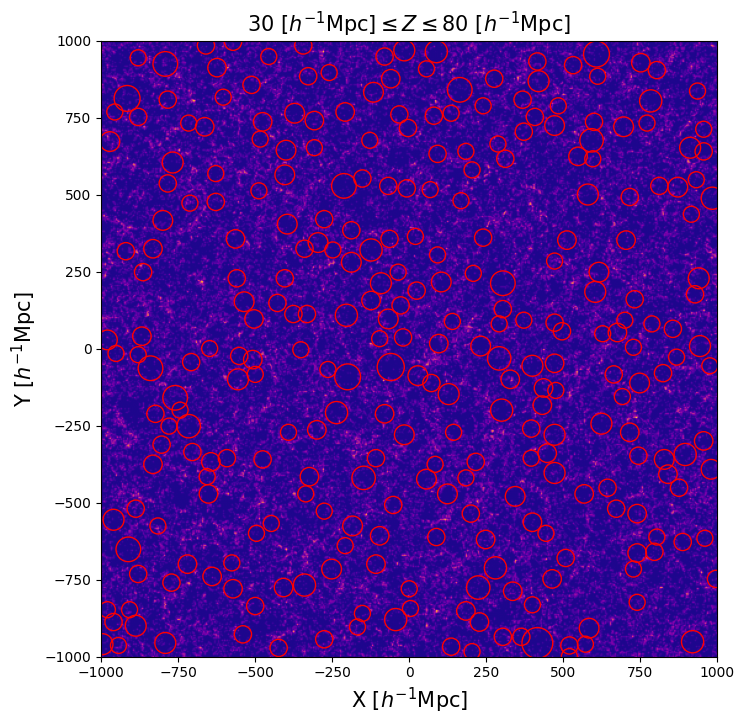

In [4]:
sv.plot_slice();

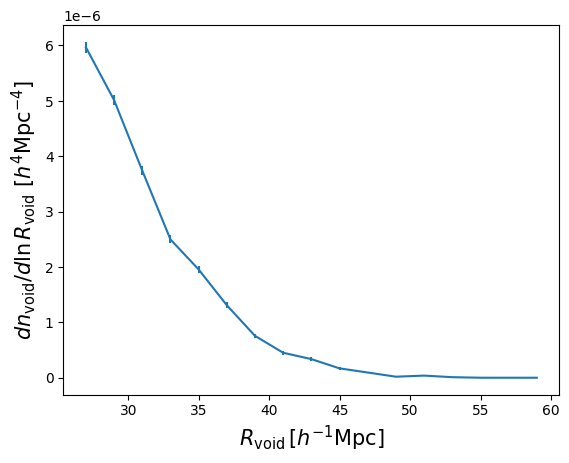

In [5]:
vsf_ax = sv.plot_size_function(label='full box')

Note that the errorbars plotted here are assuming Poisson distributed void number counts and not necessarily the true errors.

# Mock survey data

Cut out a non-cubic portion of the box and provide random positions to estimate the geometry.

In [6]:
L = 1000          # box length of portion
rand_factor = 50  # number of random positions to generate

# cut box positions
pos_small = pos[(pos > 0).all(axis=1) & (pos < L).all(axis=1)]
del pos

# generate randoms
randoms = np.random.random((rand_factor * pos_small.shape[0], 3)) * L

# slice portion of the cube in half
randoms = randoms[randoms[:,2] / randoms[:,1]<=1]
pos_small = pos_small[pos_small[:,2] / pos_small[:,1]<=1]
# save true values for comparison
cutout_vol_true = 1000**3 / 2
cutout_rho_true = pos_small.shape[0] / cutout_vol_true

Plot the cutout data positions.

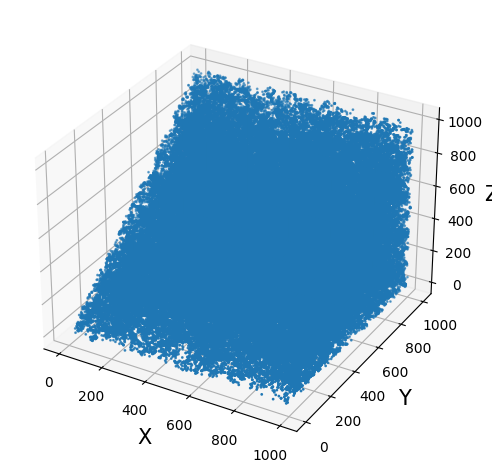

In [7]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(*pos_small.transpose(), s=1)
ax.set_xlabel('X', fontsize=15);
ax.set_ylabel('Y', fontsize=15);
ax.set_zlabel('Z', fontsize=15);
plt.tight_layout()

Run void-finding on cutout.

In [8]:
sv = SphericalVoids(data_positions=pos_small,
                    random_positions=randoms,
                    cellsize=cellsize)
sv.run_voidfinding()

16:18:55 | INFO | meshbuilder.py | __init__ | Ln54 | Loading survey-like data
16:18:55 | INFO | meshbuilder.py | size_mesh | Ln299 | Estimating volume and average galaxy separation (Ngal = 253055)
16:19:10 | INFO | meshbuilder.py | create_mesh | Ln373 | Estimating mesh density (nmesh=[276 276 276])
16:19:14 | INFO | meshbuilder.py | _set_mesh_density | Ln210 | Applying initial smoothing of R=3.5 Mpc/h to the density field
16:19:15 | INFO | meshbuilder.py | _set_mesh_density | Ln232 | 49x number of randoms used
16:19:16 | INFO | 4177581555.py | <module> | Ln1 | Building k-d trees
16:19:20 | INFO | 4177581555.py | <module> | Ln4 | Running spherical void-finder with 8 threads (delta < -0.80)
16:19:21 | INFO | 4177581555.py | <module> | Ln4 | No cells with delta < -0.80 for R=60.0 Mpc/h
16:19:21 | INFO | 4177581555.py | <module> | Ln4 | No cells with delta < -0.80 for R=58.0 Mpc/h
16:19:22 | INFO | 4177581555.py | <module> | Ln4 | No cells with delta < -0.80 for R=56.0 Mpc/h
16:19:22 | INF

Analyse the void-finding outputs and compare to results on the entire box.

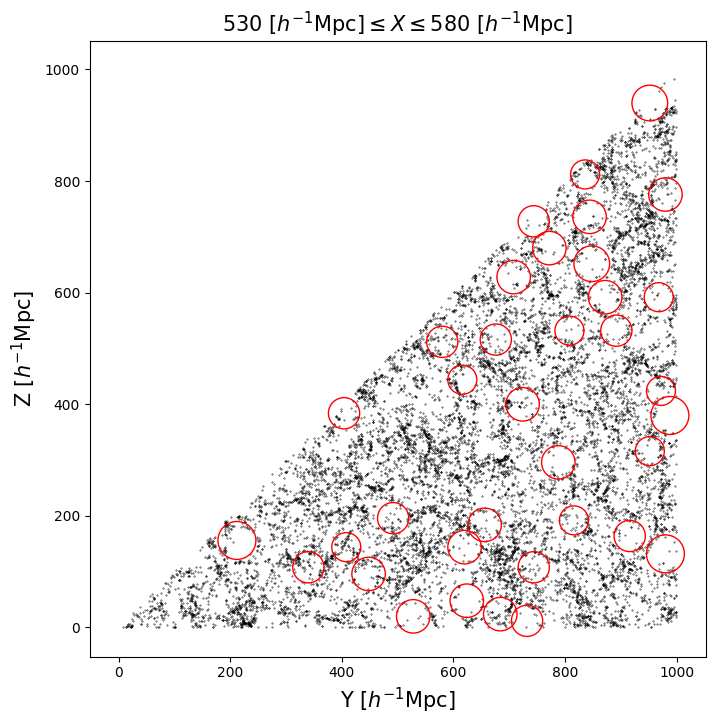

In [9]:
sv.plot_slice(slice_axis='X', slice_range=(530, 580), data_positions=pos_small);

        True        | Estimated
Volume: 500000000.0 | 510672192.0


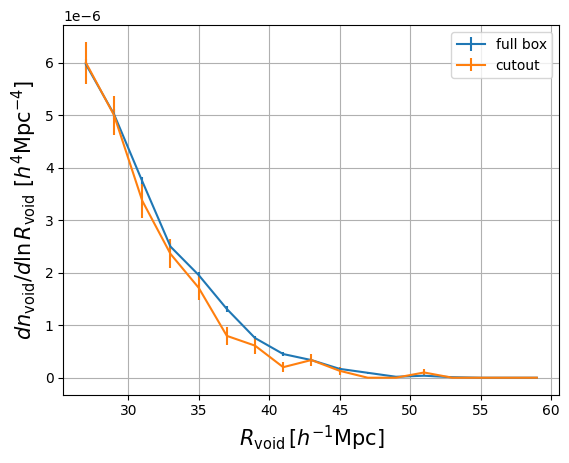

In [10]:
print(f'        True        | Estimated\nVolume: {cutout_vol_true} | {sv.volume}')

sv.plot_size_function(ax=vsf_ax, legend=True, grid=True, label='cutout')
display(vsf_ax.figure)

# Add observational weights (e.g. varying number density)

Generate a synthetic number density profile.

In [11]:
def prob(x, L, x_slope=0.5):
    x_weighted = np.ones(len(x))
    m = 1 / L / (x_slope - 1)
    C = 1 / (1 - x_slope)
    x_weighted[x > L* x_slope] = m * x[x > L * x_slope] + C
    return x_weighted

Text(0.5, 0, 'Y [$h^{-1}$ Mpc]')

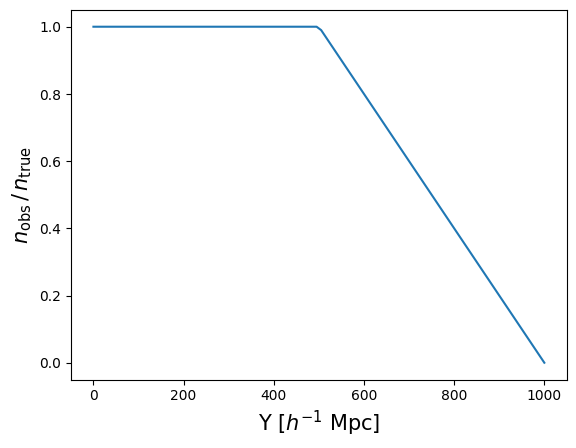

In [12]:
x = np.linspace(0, L, 100)
plt.plot(x, prob(x, L))
plt.ylabel(r'$n_{\rm obs} \,/\, n_{\rm true}$', fontsize=15)
plt.xlabel('Y [$h^{-1}$ Mpc]', fontsize=15)

Subsample data according to profile.

In [13]:
weights = prob(pos_small[:,1], L)
N_samp = weights.sum()
weights /= N_samp
subsample = np.random.choice(range(len(pos_small)), replace=False, size=int(N_samp), p=weights)
pos_nr = pos_small[subsample]

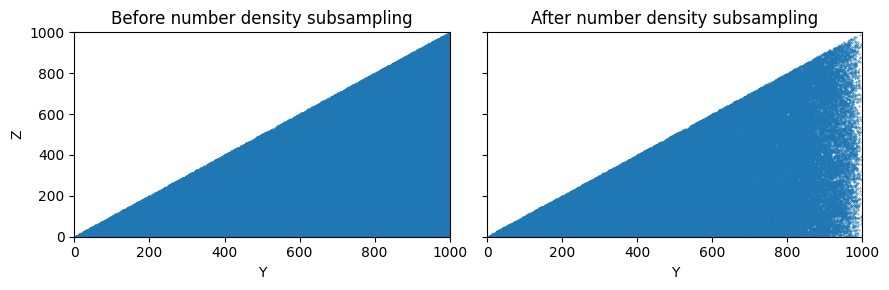

In [14]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(9,3), sharey=True)
ax1.scatter(pos_small[:,1], pos_small[:,2], s=0.1)
ax2.scatter(pos_nr[:,1], pos_nr[:,2], s=0.1)
ax1.set_ylabel('Z')
ax1.set_xlabel('Y')
ax2.set_xlabel('Y')
ax1.set_xlim(0, L)
ax1.set_ylim(0, L)
ax2.set_xlim(0, L)
ax2.set_ylim(0, L)
ax1.set_title('Before number density subsampling')
ax2.set_title('After number density subsampling')
plt.tight_layout()

Weight the randoms to account for variation in number density.

In [15]:
random_weights = prob(randoms[:,1], L)
del pos_small

Run void-finding on cutout with varying number density.

In [16]:
sv = SphericalVoids(data_positions=pos_nr, 
                    random_positions=randoms,
                    random_weights=random_weights,
                    cellsize=cellsize)
sv.run_voidfinding()

16:19:45 | INFO | meshbuilder.py | __init__ | Ln54 | Loading survey-like data
16:19:45 | INFO | meshbuilder.py | size_mesh | Ln299 | Estimating volume and average galaxy separation (Ngal = 146884)
16:19:58 | INFO | meshbuilder.py | create_mesh | Ln373 | Estimating mesh density (nmesh=[276 276 276])
16:20:03 | INFO | meshbuilder.py | _set_mesh_density | Ln210 | Applying initial smoothing of R=4.2 Mpc/h to the density field
16:20:04 | INFO | meshbuilder.py | _set_mesh_density | Ln232 | 49x number of randoms used
16:20:04 | INFO | 3930880798.py | <module> | Ln1 | Building k-d trees
16:20:09 | INFO | 3930880798.py | <module> | Ln5 | Running spherical void-finder with 8 threads (delta < -0.80)
16:20:09 | INFO | 3930880798.py | <module> | Ln5 | No cells with delta < -0.80 for R=60.0 Mpc/h
16:20:10 | INFO | 3930880798.py | <module> | Ln5 | No cells with delta < -0.80 for R=58.0 Mpc/h
16:20:10 | INFO | 3930880798.py | <module> | Ln5 | No cells with delta < -0.80 for R=56.0 Mpc/h
16:20:11 | INF

        True        | Estimated
Volume: 500000000.0 | 492437664.0


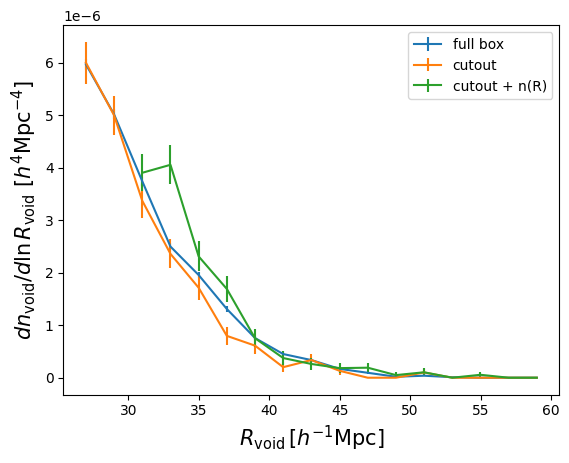

In [17]:
print(f'        True        | Estimated\nVolume: {cutout_vol_true} | {sv.volume}')

sv.plot_size_function(ax=vsf_ax, legend=True, grid=True, label='cutout + n(R)')
display(vsf_ax.figure)

When using the default input radii, the void-finder will not detect voids at any radius smaller than that at which voids begin being detected on a completely random sample of the same density (spurious detections). This is why the `cutout + n(R)` case does not extend to the lowest radii (due to the lower estimated density) and ensures a clean sample for cosmological analysis. However, this can be easily overridden by providing a set of input radii when instantiating the ```SphericalVoids``` class.